# Parameterized Alpha Analysis of Multiple MGnify Studies

![MGnify](../assets/figs/mgnify_banner.png)

This notebook runs a complete bacterial diversity analysis using a configuration dictionary to control all parameters.

**Key features:**
1. Single configuration dictionary for all analysis parameters
4. Automated output management

**Pipeline with options**
1. Counts
2. Filter on minimum reads per sample
3. Filtering based on prok vs euk
4. Three cases of preprocessing for the final `alpha` diversity analysis

## Setup and Imports

In [1]:
from pathlib import Path

# Dataframes and display
import pandas as pd
import numpy as np
from tqdm import tqdm

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

# Warning verbosity
import warnings 
warnings.filterwarnings(action="ignore")

from mgnify_methods.utils.logging import get_logger

logger = get_logger('nb_multiple_studies', level="INFO")
logger.info("Hello from mgnify_methods")
%matplotlib inline 

INFO | nb_multiple_studies | Hello from mgnify_methods


In [2]:
# Import all required functions
from momics.taxonomy import (
    fill_taxonomy_placeholders,
    rarefy_table,
)

from mgnify_methods.taxonomy import (
    aggregate_by_taxonomic_level,
    fill_lower_taxa,
    pivot_taxonomic_data,
    remove_singletons_per_sample,
)

from mgnify_methods.utils.plot import (
    plot_feature_reads_hist,
    plot_taxonomic_overlap,
    violin_plot_taxon,
)

from mgnify_methods.metacomp.rarefaction import (
    rarefaction_curve,
    calc_rarefaction_curves,
    calculate_min_rarefaction_depth,
)
from mgnify_methods.metacomp.transforms import (
    apply_preprocessing_method,
    apply_transform_method,
)
from mgnify_methods.metacomp.diversity import alpha_diversity_analysis
from mgnify_methods.utils.io import (
    load_taxonomy_summary,
    filter_tax_summary,
    assert_taxonomy_integrity,
    process_analysis_metadata,
    filter_analysis_meta,
    process_samples_metadata,
    enhance_samples_metadata,
    filter_number_reads,
)

from mgnify_methods import TaxonomyTable, AbundanceTable

# Beta diversity
from skbio.diversity import beta_diversity
from skbio.stats.ordination import pcoa

## Configuration Dictionary

All analysis parameters are defined here. Modify this dictionary to control the entire analysis flow.

In [3]:
# ============================================================================
# ANALYSIS CONFIGURATION
# ============================================================================

CONFIG = {
    # === Data Sources ===
    'datasets': {
        'OSD2018': ['MGYS00006608', 'mgnify_data/ERP124424_taxonomy_abundances_SSU_v5.0.tsv'],
        'OSD2019': ['MGYS00006607', 'mgnify_data/ERP124431_taxonomy_abundances_SSU_v5.0.tsv'],
        'Sola': ['MGYS00006680', 'mgnify_data/SRP237882_taxonomy_abundances_SSU_v5.0.tsv'],
        # 'Tara': ['MGYS00000492', 'mgnify_data/ERP003634_taxonomy_abundances_SSU_v5.0.tsv'],
        'Biscay': ['MGYS00006682', 'mgnify_data/SRP334933_taxonomy_abundances_SSU_v5.0.tsv'],
        'Baltic': ['MGYS00006678', 'mgnify_data/ERP140185_taxonomy_abundances_SSU_v5.0.tsv'],
        'BBMO': ['MGYS00006675', 'mgnify_data/ERP122219_taxonomy_abundances_SSU_v5.0.tsv'],
        'Svalbard': ['MGYS00003725', 'mgnify_data/ERP106348_taxonomy_abundances_SSU_v5.0.tsv'],
        'Helgoland': ['MGYS00006686', 'mgnify_data/ERP144826_taxonomy_abundances_SSU_v5.0.tsv'],
        'Fram': ['MGYS00006714', 'mgnify_data/ERP151329_taxonomy_abundances_SSU_v5.0.tsv'],

    },
    
    # === Output Configuration ===
    'output': {
        'use_timestamp': True,  # Create timestamped output folder
        'cache_dir': 'analysis_cache',  # Cache directory for downloaded data
    },
    
    # === Filtering Parameters ===
    'filtering': {
        'min_reads_cutoff': 25000,  # Minimum reads per sample
        # 'prevalence_percent': 0.005,  # Prevalence cutoff (0.5%)
    },
    
    # === Taxonomic Settings ===
    'taxonomy': {
        'ranks': ['superkingdom', 'kingdom', 'phylum', 'class', 'order', 'family', 'genus', 'species'],
        'analysis_level': 'phylum', #, 'class', 'order', 'family', 'genus',  # Levels for detailed analysis
        'filter_to_bacteria': True,  # Focus only on bacterial taxa
    },
    
    # === Sample Selection ===
    'samples': {
        'sample_type': 'prok',  # 'prok' or 'euk'
    },
    
    # === Preprocess Settings ===
    'preprocess': {
        'method_params': {
            'rarefaction': {
                'depth': None,  # None = auto-calculate minimum depth
                'n_points': 50,  # Number of points for rarefaction curves
            },
        },
    },
    
    # === Diversity Analysis ===
    'diversity': {
        'alpha': {
            'enabled': True,
            'dropna': False,  # Drop NA values during aggregation
            'remove_singletons': False,  # Remove taxa appearing only once per sample
            'rarefy': False,  # Rarefy samples to minimum depth before alpha diversity analysis
        },
    },
    
    # === Feature Analysis ===
    'feature': 'study_tag',  # features to analyze
    
    # === Plot Flags ===
    'plots': {
        'reads_histogram': True,
        'taxonomic_overlap_venn': True,
        'rarefaction_curves': True,
        'rarefaction_mean_std': True,
        'rarefaction_mean_ci': True,
        'rarefaction_individual': False,  # Can be very cluttered
        'alpha_diversity': True,
        'beta_diversity_pcoa': False,
        'taxa_prevalence_violin': True,
        'feature_rarefaction': True,  # Rarefaction curves per feature value
        'save_figures': False,  # Save figures to output folder
        'dpi': 300,  # DPI for saved figures
    },
}

print("Configuration loaded successfully!")
print(f"\nDatasets: {list(CONFIG['datasets'].keys())}")
print(f"Taxonomic level for analysis: {CONFIG['taxonomy']['analysis_level']}")
print(f"Feature to analyze: {CONFIG['feature']}")

Configuration loaded successfully!

Datasets: ['OSD2018', 'OSD2019', 'Sola', 'Biscay', 'Baltic', 'BBMO', 'Svalbard', 'Helgoland', 'Fram']
Taxonomic level for analysis: phylum
Feature to analyze: study_tag


## Initialize Output Directories

In [4]:
# Extract configuration
TAXONOMY_RANKS = CONFIG['taxonomy']['ranks']
ds = CONFIG['datasets']

# Create output directories
if CONFIG['output']['use_timestamp']:
    stamp = pd.Timestamp.now().strftime('%Y%m%d_%H%M')
    OUT_FOLDER = Path('analysis_' + stamp).resolve()
else:
    OUT_FOLDER = Path('analysis_latest').resolve()

ANALYSIS_CACHE = Path(CONFIG['output']['cache_dir']).resolve()

# add OUT_FOLDER to config for later use
CONFIG['output']['out_folder'] = str(OUT_FOLDER)
CONFIG['input'] = {'cache_dir': str(ANALYSIS_CACHE)}

for folder in [OUT_FOLDER, ANALYSIS_CACHE]:
    folder.mkdir(parents=True, exist_ok=True)
    print(f"Directory ready: {folder}")

# Save configuration to output folder
import json
config_path = OUT_FOLDER / 'analysis_config.json'
with open(config_path, 'w') as f:
    json.dump(CONFIG, f, indent=2)
print(f"\nConfiguration saved to: {config_path}")

Directory ready: /home/david-palecek/coding/emo-bon/mgnify-methods/mgnify-methods/notebooks/analysis_20260210_1635
Directory ready: /home/david-palecek/coding/emo-bon/mgnify-methods/mgnify-methods/notebooks/analysis_cache

Configuration saved to: /home/david-palecek/coding/emo-bon/mgnify-methods/mgnify-methods/notebooks/analysis_20260210_1635/analysis_config.json


## Load Metadata from MGnify

In [5]:
# Fetch analysis metadata
analysis_meta = process_analysis_metadata(ANALYSIS_CACHE, ds)
analysis_meta = analysis_meta.query("`attributes.pipeline-version` == 5.0")
print(f"Loaded {len(analysis_meta)} analyses")

# Fetch and enhance sample metadata
samples_meta = process_samples_metadata(ANALYSIS_CACHE, ds)
samples_meta = enhance_samples_metadata(samples_meta)
print(f"Loaded {len(samples_meta)} samples")

INFO | mgnify_methods.utils.io | Analysis OSD2018 has 62 samples.
INFO | mgnify_methods.utils.io | Analysis OSD2019 has 48 samples.
INFO | mgnify_methods.utils.io | Analysis Sola has 283 samples.
INFO | mgnify_methods.utils.io | Analysis Biscay has 52 samples.
INFO | mgnify_methods.utils.io | Analysis Baltic has 665 samples.
INFO | mgnify_methods.utils.io | Analysis BBMO has 249 samples.
INFO | mgnify_methods.utils.io | Analysis Svalbard has 159 samples.
INFO | mgnify_methods.utils.io | Analysis Helgoland has 357 samples.
INFO | mgnify_methods.utils.io | Analysis Fram has 205 samples.
INFO | mgnify_methods.utils.io | Analysis OSD2018 has 62 samples.
INFO | mgnify_methods.utils.io | Analysis OSD2019 has 48 samples.
INFO | mgnify_methods.utils.io | Analysis Sola has 283 samples.
INFO | mgnify_methods.utils.io | Analysis Biscay has 52 samples.
INFO | mgnify_methods.utils.io | Analysis Baltic has 665 samples.
INFO | mgnify_methods.utils.io | Analysis BBMO has 249 samples.
INFO | mgnify_met

Loaded 2002 analyses
Loaded 1859 samples


## Filter Samples by Read Count


=== Reads Distribution (Unfiltered) ===
Samples not matched to study_tag metadata: 146


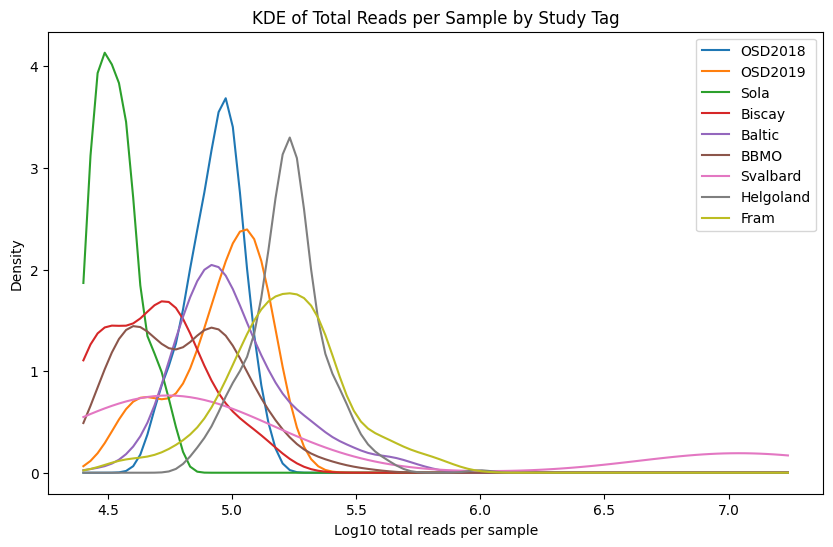

INFO | mgnify_methods.utils.io | Dropping 0 samples with less than 25000 reads: []



Filtering samples with < 25000 reads: 0 samples to remove
Remaining analyses after filtering: 1883

=== Reads Distribution (Filtered) ===
Samples not matched to study_tag metadata: 146


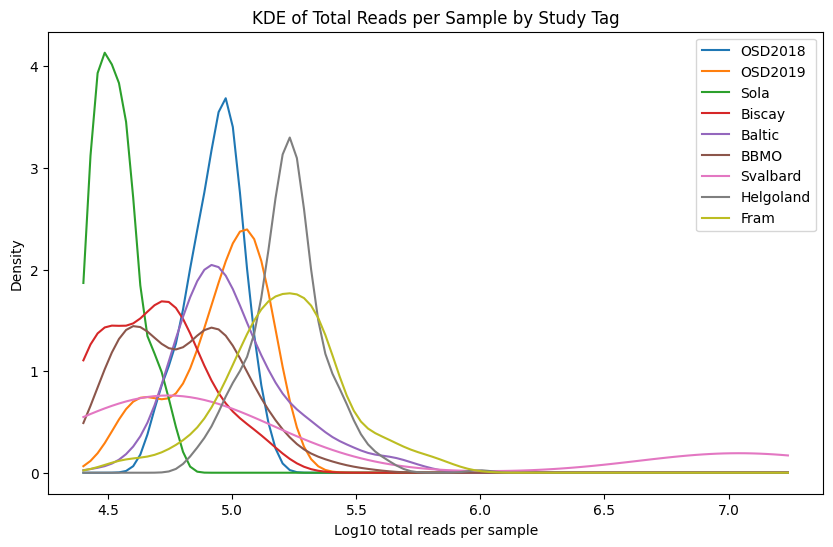

In [8]:
# Plot reads distribution before filtering
if CONFIG['plots']['reads_histogram']:
    print("\n=== Reads Distribution (Unfiltered) ===")
    total_dict = plot_feature_reads_hist(
        analysis_meta=analysis_meta,
        samples_meta=samples_meta,
        feature=CONFIG['feature'],
        name=f'{CONFIG["feature"]}_reads_unfiltered.png' if CONFIG['plots']['save_figures'] else None,
        out_dir=OUT_FOLDER if CONFIG['plots']['save_figures'] else None,
        use_robust_save=False,
        bins=100,
    )

# Apply filtering
cutoff = CONFIG['filtering']['min_reads_cutoff']
to_drop = filter_number_reads(total_dict, cutoff)
print(f"\nFiltering samples with < {cutoff} reads: {len(to_drop)} samples to remove")

for sample in to_drop:
    analysis_meta = analysis_meta[analysis_meta.index != sample]

print(f"Remaining analyses after filtering: {len(analysis_meta)}")

# Plot reads distribution after filtering
if CONFIG['plots']['reads_histogram']:
    print("\n=== Reads Distribution (Filtered) ===")
    total_dict = plot_feature_reads_hist(
        analysis_meta=analysis_meta,
        samples_meta=samples_meta,
        feature=CONFIG['feature'],
        name=f'{CONFIG["feature"]}_reads_unfiltered.png' if CONFIG['plots']['save_figures'] else None,
        out_dir=OUT_FOLDER if CONFIG['plots']['save_figures'] else None,
        use_robust_save=False,
        bins=100,
    )

## Load and Merge Taxonomy Data

In [7]:
# Get data folder path
root_folder = Path.cwd().parent
data_folder = root_folder / 'data'

df_tax_summary = load_taxonomy_summary(ds, data_folder)

INFO | mgnify_methods.utils.io | Loaded OSD2018: (1981, 62)
INFO | mgnify_methods.utils.io | Loaded OSD2019: (1708, 48)
INFO | mgnify_methods.utils.io | Loaded Sola: (3484, 283)
INFO | mgnify_methods.utils.io | Loaded Biscay: (118, 52)
INFO | mgnify_methods.utils.io | Loaded Baltic: (4316, 665)
INFO | mgnify_methods.utils.io | Loaded BBMO: (2503, 249)
INFO | mgnify_methods.utils.io | Loaded Svalbard: (1505, 81)
INFO | mgnify_methods.utils.io | Loaded Helgoland: (2241, 165)
INFO | mgnify_methods.utils.io | Loaded Fram: (1428, 205)
INFO | mgnify_methods.utils.io | 
Merged taxonomy table: (7265, 1810)


## Synchronize Metadata and Taxonomy Tables

In [8]:
# Remove samples not in metadata
analysis_meta = filter_analysis_meta(analysis_meta, samples_meta)
df_tax_summary = filter_tax_summary(df_tax_summary, analysis_meta)

# check data integrity
assert_taxonomy_integrity(df_tax_summary, analysis_meta)

INFO | mgnify_methods.utils.io | Dropped 143 samples from analysis_meta: 1883 -> 1740
INFO | mgnify_methods.utils.io | 
Taxonomy samples before filtering: 1810
INFO | mgnify_methods.utils.io | Taxonomy samples after filtering: 1550
INFO | mgnify_methods.utils.io | 
Removing 604 taxa with all zero counts


AssertionError: Sample count mismatch

In [9]:
analysis_meta['relationships.sample.data.id'].size, len(df_tax_summary.columns)

(1740, 1550)

## Convert to TaxonomyTable Format

In [9]:
# Convert abundance table to taxonomy table
abundance_table = AbundanceTable(df_tax_summary.reset_index(), source='tax_mgnify_raw')
ncbi_flag, taxonomy_table = abundance_table.to_taxonomy_table()

taxonomy_table.df.sort_values(by=['source material ID', 'abundance'], inplace=True)

# Fill missing taxonomic information
taxonomy_table.df = fill_lower_taxa(taxonomy_table.df, TAXONOMY_RANKS)
taxonomy_table.df = fill_taxonomy_placeholders(taxonomy_table.df, TAXONOMY_RANKS)

if not taxonomy_table.df.index.name == 'source material ID':
    taxonomy_table.df = taxonomy_table.df.set_index('source material ID')

print(f"\nTaxonomy table ready: {taxonomy_table.df.shape}")

INFO | mgnify_methods.tables.tables | Converting source: tax_mgnify_raw


WARNING | mgnify_methods.tables.tables | DataFrame is abundance without ncbi_tax_id data.
INFO | mgnify_methods.tables.tables | self.source before conversion to Taxonomy table: tax_mgnify_raw
INFO | mgnify_methods.tables.tables | Converting source: tax_processed
INFO | mgnify_methods.tables.sources.converters | Abundance dtype after conversion: uint32
INFO | mgnify_methods.tables.tables | Validating source: tax_processed



Taxonomy table ready: (449012, 9)


## Filter to Target Sample Type
- either `prok` or `euk`

In [10]:
# Get sample list for selected sample type
sample_type = CONFIG['samples']['sample_type']
sample_list = samples_meta[samples_meta['sample_type'] == sample_type]['id'].tolist()
data_list = analysis_meta[analysis_meta['relationships.sample.data.id'].isin(sample_list)].index.tolist()

# Filter taxonomy table
taxonomy_table.df_filt = taxonomy_table.df[taxonomy_table.df.index.isin(data_list)]

print(f"Filtered to {sample_type} samples: {len(data_list)} samples")
print(f"Filtered taxonomy table: {taxonomy_table.df_filt.shape}")

Filtered to prok samples: 1740 samples
Filtered taxonomy table: (449012, 9)


## Taxonomic Overlap Analysis

In [11]:
# if CONFIG['plots']['taxonomic_overlap_venn']:
#     logger.info("\n=== Taxonomic Overlap Analysis ===")
#     plot_taxonomic_overlap(taxonomy_table, analysis_meta, CONFIG)

## Preprocessing
- aggregate by taxonomic level (this is done on the Taxonomy table)
- then convert to abundance table
- then prevalence cutoff
- then preprocessing normlization `rarefaction`, `tss`, `tss_sqrt`

**This is supposed to be rewritten using only the OOP TaxonomyTable and AbendanceTable**

In [11]:
tax_level = CONFIG['taxonomy']['analysis_level']
table = aggregate_by_taxonomic_level(
    taxonomy_table.df_filt, level=tax_level, dropna=CONFIG['diversity']['alpha']['dropna']
)

In [12]:
abundance_table = pivot_taxonomic_data(table)
type(abundance_table)

pandas.core.frame.DataFrame

## Apha diversity analysis
- Needs to be on counts

**Three cases**
1. No additional preprocessing
2. Only removing singletons
3. Only rarefaction

Both removing singletons and rarefaction is not recommended

In [13]:
tax_level = CONFIG['taxonomy']['analysis_level']

### Case 1, no preprocessing

INFO | mgnify_methods.metacomp.diversity | 
=== Alpha Diversity Analysis ===
INFO | mgnify_methods.metacomp.diversity | Analyzing at phylum level...
INFO | mgnify_methods.metacomp.diversity | Data: 1550 samples, 213 taxa
INFO | mgnify_methods.metacomp.diversity | Study distribution: {'Baltic': 656, 'BBMO': 212, 'Fram': 203, 'Helgoland': 164, 'Sola': 107, 'Svalbard': 77, 'OSD2018': 58, 'OSD2019': 48, 'Biscay': 25}
INFO | mgnify_methods.metacomp.diversity | 
Saved diversity results to: /home/david-palecek/coding/emo-bon/mgnify-methods/mgnify-methods/notebooks/analysis_20260210_1547/alpha_diversity_phylum_no_processing.csv


Calculated diversity for 1550 samples


shannon                                                  simpson  \
            count   mean    std    min    25%    50%    75%    max   count   
study_tag                                                                    
BBMO        212.0  1.102  0.301  0.123  0.911  1.108  1.324  1.834   212.0   
Baltic      656.0  1.710  0.342  0.339  1.478  1.707  1.938  2.685   656.0   
Biscay       25.0  0.695  0.317  0.136  0.465  0.693  0.877  1.319    25.0   
Fram        203.0  1.480  0.239  0.786  1.345  1.505  1.631  2.045   203.0   
Helgoland   164.0  1.377  0.465  0.137  1.132  1.422  1.734  2.262   164.0   
OSD2018      58.0  1.458  0.285  0.506  1.296  1.490  1.647  1.926    58.0   
OSD2019      48.0  1.352  0.219  0.843  1.178  1.384  1.502  1.765    48.0   
Sola        107.0  1.347  0.165  0.900  1.238  1.379  1.476  1.681   107.0   
Svalbard     77.0  1.300  0.464  0.145  0.987  1.288  1.581  2.563    77.0   

                                                           observed_otus  \
            mean    std    min    25%    50%    75%    max         count   
study_tag                                                                  
BBMO       0.525  0.146  0.037  0.424  0.550  0.633  0.802         212.0   
Baltic     0.718  0.110  0.109  0.668  0.742  0.789  0.913         656.0   
Biscay     0.394  0.167  0.059  0.277  0.419  0.514  0.658          25.0   
Fram       0.678  0.071  0.423  0.643  0.698  0.725  0.798         203.0   
Helgoland  0.591  0.181  0.046  0.525  0.633  0.724  0.834         164.0   
OSD2018    0.675  0.116  0.222  0.627  0.698  0.749  0.833          58.0   
OSD2019    0.634  0.096  0.365  0.572  0.657  0.701  0.771          48.0   
Sola       0.617  0.068  0.393  0.573  0.625  0.672  0.742         107.0   
Svalbard   0.576  0.170  0.049  0.465  0.630  0.691  0.870          77.0   

                                                          chao1          \
             mean     std   min    25%   50%   75%   max  count    mean   
study_tag                                                                 
BBMO       26.099   8.506  11.0  20.00  25.0  33.0  52.0  212.0  31.691   
Baltic     41.855  12.062   7.0  35.00  41.0  48.0  84.0  656.0  46.379   
Biscay      7.320   4.507   2.0   4.00   7.0  10.0  19.0   25.0   7.910   
Fram       39.862   7.424  20.0  35.50  40.0  44.0  58.0  203.0  48.466   
Helgoland  48.555  12.897  21.0  44.00  53.0  58.0  73.0  164.0  53.401   
OSD2018    38.759  13.334  11.0  30.25  37.5  48.0  71.0   58.0  46.717   
OSD2019    42.792  16.856  15.0  30.00  44.5  56.0  80.0   48.0  51.432   
Sola       32.720   8.882  19.0  27.00  31.0  36.0  70.0  107.0  45.773   
Svalbard   32.195  11.143  12.0  23.00  34.0  40.0  56.0   77.0  38.196   

                                                          
              std    min     25%     50%     75%     max  
study_tag                                                 
BBMO       12.815  11.00  22.830  29.100  40.062   87.75  
Baltic     14.221   7.00  37.688  44.600  53.600   98.00  
Biscay      5.246   2.00   4.000   7.000  11.000   24.00  
Fram       13.169  21.00  41.000  47.111  55.000  135.00  
Helgoland  14.447  23.25  45.425  56.125  62.312  107.00  
OSD2018    17.577  11.00  34.850  46.071  55.469  114.50  
OSD2019    21.667  17.50  34.025  54.814  63.000  120.50  
Sola       16.522  22.20  33.417  42.250  53.550  100.00  
Svalbard   15.162  12.00  27.500  39.200  44.600  103.60

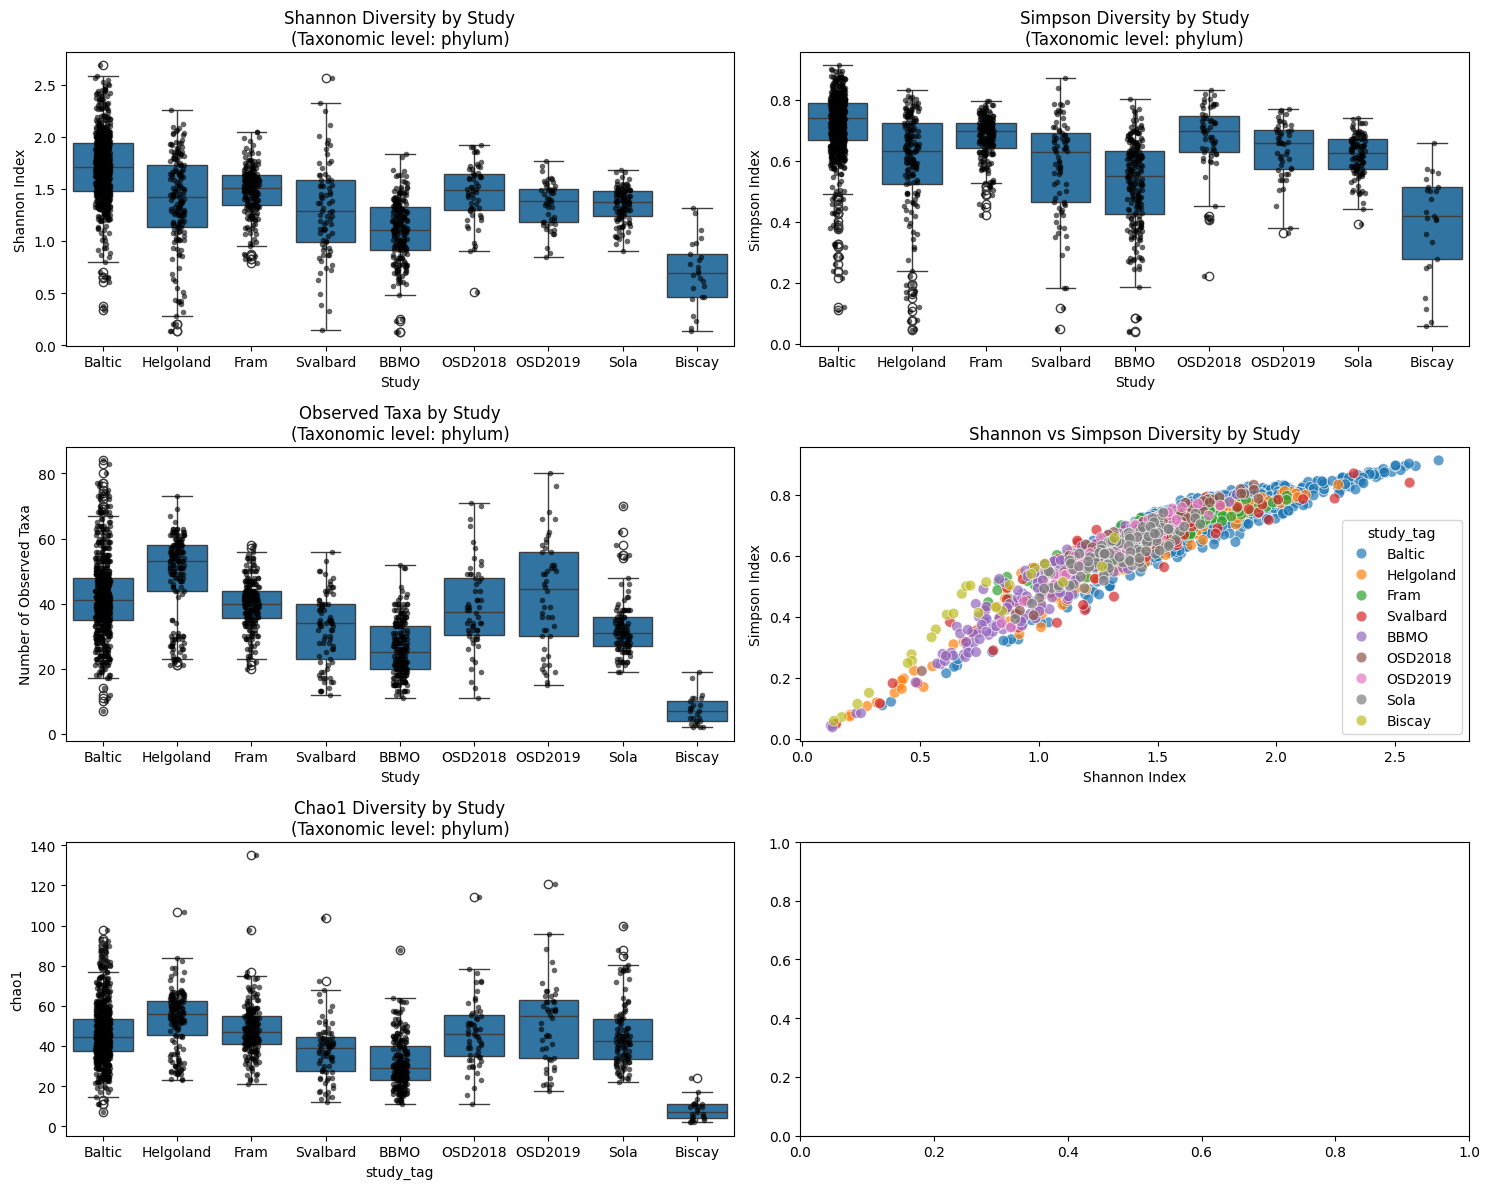

INFO | mgnify_methods.stats | 
INFO | mgnify_methods.stats | STATISTICAL COMPARISON OF ALPHA DIVERSITY BETWEEN STUDIES
INFO | mgnify_methods.stats | ============================================================
INFO | mgnify_methods.stats | 
SHANNON - Kruskal-Wallis
INFO | mgnify_methods.stats | H=537.716, p=0.0000, epsilon²=0.344
INFO | mgnify_methods.stats | 
SIMPSON - Kruskal-Wallis
INFO | mgnify_methods.stats | H=484.817, p=0.0000, epsilon²=0.309
INFO | mgnify_methods.stats | 
OBSERVED_OTUS - Kruskal-Wallis
INFO | mgnify_methods.stats | H=464.468, p=0.0000, epsilon²=0.296
INFO | mgnify_methods.stats | 
CHAO1 - Kruskal-Wallis
INFO | mgnify_methods.stats | H=322.971, p=0.0000, epsilon²=0.204


,Metric,Comparison,Test,Statistic,RawP,DeltaMedian,RBC,CliffDelta,KW_H,KW_P,KW_EpsilonSq,AdjP
0,shannon,Baltic vs Helgoland,Pairwise MW,76216.0,1.395668e-16,0.284769,-0.416865,0.416865,537.716321,5.644921e-111,0.343748,4.466138e-15
1,shannon,Baltic vs Fram,Pairwise MW,94441.0,1.930931e-19,0.201448,-0.418374,0.418374,537.716321,5.644921e-111,0.343748,6.372071e-18
2,shannon,Baltic vs Svalbard,Pairwise MW,38897.0,8.476347e-15,0.418536,-0.540109,0.540109,537.716321,5.644921e-111,0.343748,2.542904e-13
3,shannon,Baltic vs BBMO,Pairwise MW,127628.0,7.527369e-75,0.598679,-0.835423,0.835423,537.716321,5.644921e-111,0.343748,2.709853e-73
4,shannon,Baltic vs OSD2018,Pairwise MW,27196.0,5.725441e-08,0.216859,-0.429563,0.429563,537.716321,5.644921e-111,0.343748,1.030579e-06
...,...,...,...,...,...,...,...,...,...,...,...,...
139,chao1,OSD2018 vs Sola,Pairwise MW,3319.5,4.609843e-01,3.821429,-0.069771,0.069771,322.971227,5.272689e-65,0.204394,1.000000e+00
140,chao1,OSD2018 vs Biscay,Pairwise MW,1440.0,1.315060e-12,39.071429,-0.986207,0.986207,322.971227,5.272689e-65,0.204394,3.419156e-11
141,chao1,OSD2019 vs Sola,Pairwise MW,3006.5,9.004154e-02,12.564286,-0.170755,0.170755,322.971227,5.272689e-65,0.204394,8.103738e-01
142,chao1,OSD2019 vs Biscay,Pairwise MW,1194.5,4.980820e-12,47.814286,-0.990833,0.990833,322.971227,5.272689e-65,0.204394,1.195397e-10


In [14]:
CONFIG['output']['alpha_tag'] = 'no_processing'
summary_case1, df_case1, stats_case1 = alpha_diversity_analysis(
    abundance_table, analysis_meta, 
    samples_meta, CONFIG,
)

### Case 2, remove singletons

INFO | nb_multiple_studies | Removed singletons per sample
INFO | mgnify_methods.metacomp.diversity | 
=== Alpha Diversity Analysis ===
INFO | mgnify_methods.metacomp.diversity | Analyzing at phylum level...
INFO | mgnify_methods.metacomp.diversity | Data: 1550 samples, 199 taxa


Removed 14 singleton features. Shape reduced from (213, 1550) → (199, 1550)


INFO | mgnify_methods.metacomp.diversity | Study distribution: {'Baltic': 656, 'BBMO': 212, 'Fram': 203, 'Helgoland': 164, 'Sola': 107, 'Svalbard': 77, 'OSD2018': 58, 'OSD2019': 48, 'Biscay': 25}
INFO | mgnify_methods.metacomp.diversity | 
Saved diversity results to: /home/david-palecek/coding/emo-bon/mgnify-methods/mgnify-methods/notebooks/analysis_20260210_1547/alpha_diversity_phylum_remove_singletons.csv


Calculated diversity for 1550 samples


shannon                                                  simpson  \
            count   mean    std    min    25%    50%    75%    max   count   
study_tag                                                                    
BBMO        212.0  1.100  0.301  0.123  0.910  1.107  1.323  1.833   212.0   
Baltic      656.0  1.709  0.342  0.339  1.478  1.705  1.938  2.684   656.0   
Biscay       25.0  0.683  0.323  0.000  0.465  0.693  0.872  1.300    25.0   
Fram        203.0  1.479  0.239  0.786  1.344  1.504  1.630  2.044   203.0   
Helgoland   164.0  1.376  0.465  0.136  1.131  1.421  1.733  2.262   164.0   
OSD2018      58.0  1.456  0.285  0.506  1.291  1.488  1.645  1.923    58.0   
OSD2019      48.0  1.350  0.219  0.841  1.176  1.382  1.500  1.762    48.0   
Sola        107.0  1.343  0.165  0.897  1.234  1.376  1.471  1.676   107.0   
Svalbard     77.0  1.294  0.458  0.145  0.986  1.287  1.580  2.543    77.0   

                                                           observed_otus  \
            mean    std    min    25%    50%    75%    max         count   
study_tag                                                                  
BBMO       0.525  0.146  0.037  0.424  0.550  0.633  0.802         212.0   
Baltic     0.718  0.110  0.109  0.668  0.742  0.789  0.913         656.0   
Biscay     0.391  0.172  0.000  0.276  0.415  0.514  0.656          25.0   
Fram       0.678  0.071  0.423  0.643  0.698  0.725  0.797         203.0   
Helgoland  0.591  0.181  0.046  0.525  0.633  0.724  0.834         164.0   
OSD2018    0.675  0.116  0.222  0.627  0.698  0.748  0.833          58.0   
OSD2019    0.634  0.096  0.365  0.572  0.657  0.701  0.771          48.0   
Sola       0.617  0.068  0.392  0.573  0.624  0.671  0.741         107.0   
Svalbard   0.576  0.170  0.049  0.465  0.630  0.689  0.870          77.0   

                                                           chao1          \
             mean     std   min    25%   50%    75%   max  count    mean   
study_tag                                                                  
BBMO       20.575   6.614  10.0  15.00  19.0  25.25  45.0  212.0  20.575   
Baltic     36.380  11.143   7.0  29.00  36.0  42.00  75.0  656.0  36.380   
Biscay      5.880   3.822   1.0   3.00   5.0   9.00  16.0   25.0   5.880   
Fram       32.419   6.190  16.0  29.00  33.0  36.00  50.0  203.0  32.419   
Helgoland  43.024  12.749  16.0  39.00  47.0  52.00  67.0  164.0  43.024   
OSD2018    30.586  12.189  11.0  22.25  28.0  38.75  61.0   58.0  30.586   
OSD2019    33.750  15.098  11.0  22.00  32.5  44.00  67.0   48.0  33.750   
Sola       22.645   6.464  13.0  19.00  22.0  25.50  54.0  107.0  22.645   
Svalbard   26.130  10.075   8.0  18.00  27.0  33.00  47.0   77.0  26.130   

                                                   
              std   min    25%   50%    75%   max  
study_tag                                          
BBMO        6.614  10.0  15.00  19.0  25.25  45.0  
Baltic     11.143   7.0  29.00  36.0  42.00  75.0  
Biscay      3.822   1.0   3.00   5.0   9.00  16.0  
Fram        6.190  16.0  29.00  33.0  36.00  50.0  
Helgoland  12.749  16.0  39.00  47.0  52.00  67.0  
OSD2018    12.189  11.0  22.25  28.0  38.75  61.0  
OSD2019    15.098  11.0  22.00  32.5  44.00  67.0  
Sola        6.464  13.0  19.00  22.0  25.50  54.0  
Svalbard   10.075   8.0  18.00  27.0  33.00  47.0

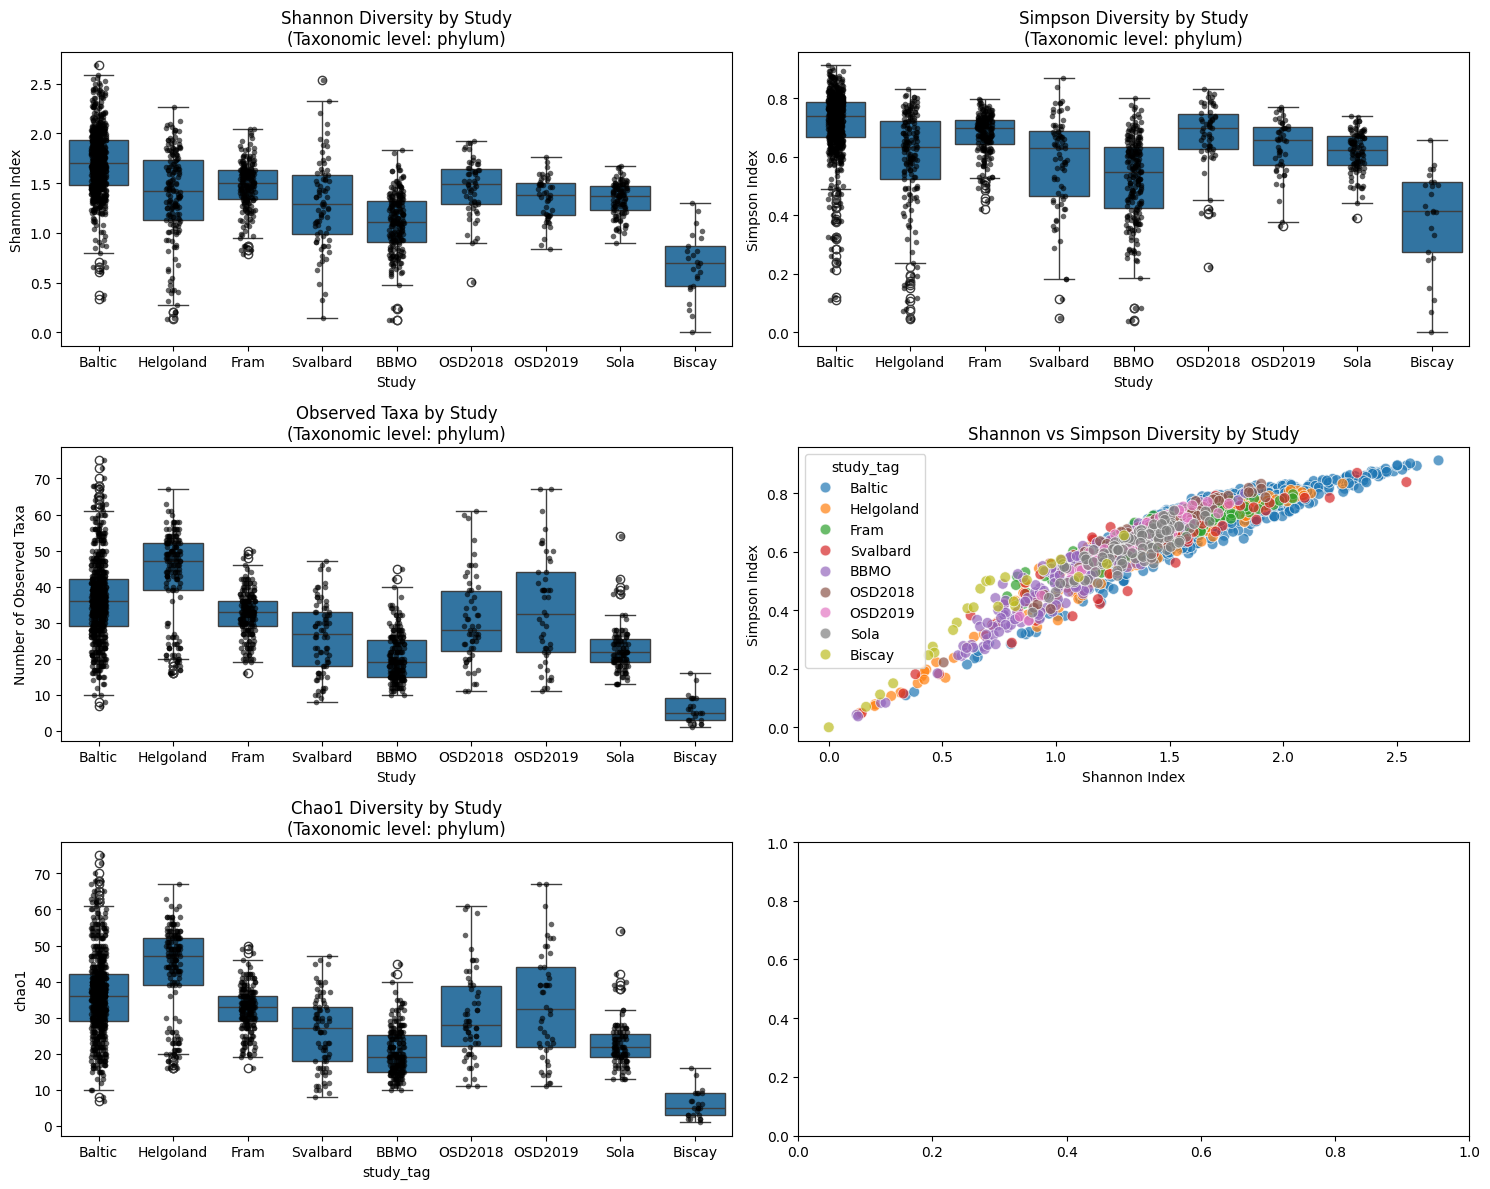

INFO | mgnify_methods.stats | 
INFO | mgnify_methods.stats | STATISTICAL COMPARISON OF ALPHA DIVERSITY BETWEEN STUDIES
INFO | mgnify_methods.stats | ============================================================
INFO | mgnify_methods.stats | 
SHANNON - Kruskal-Wallis
INFO | mgnify_methods.stats | H=540.828, p=0.0000, epsilon²=0.346
INFO | mgnify_methods.stats | 
SIMPSON - Kruskal-Wallis
INFO | mgnify_methods.stats | H=485.774, p=0.0000, epsilon²=0.310
INFO | mgnify_methods.stats | 
OBSERVED_OTUS - Kruskal-Wallis
INFO | mgnify_methods.stats | H=568.724, p=0.0000, epsilon²=0.364
INFO | mgnify_methods.stats | 
CHAO1 - Kruskal-Wallis
INFO | mgnify_methods.stats | H=568.724, p=0.0000, epsilon²=0.364


,Metric,Comparison,Test,Statistic,RawP,DeltaMedian,RBC,CliffDelta,KW_H,KW_P,KW_EpsilonSq,AdjP
0,shannon,Baltic vs Helgoland,Pairwise MW,76193.0,1.498409e-16,0.283795,-0.416437,0.416437,540.828204,1.211745e-111,0.345768,4.794908e-15
1,shannon,Baltic vs Fram,Pairwise MW,94470.0,1.772331e-19,0.200994,-0.418809,0.418809,540.828204,1.211745e-111,0.345768,5.848691e-18
2,shannon,Baltic vs Svalbard,Pairwise MW,39131.0,2.941257e-15,0.418386,-0.549374,0.549374,540.828204,1.211745e-111,0.345768,8.823772e-14
3,shannon,Baltic vs BBMO,Pairwise MW,127643.0,6.901619e-75,0.598521,-0.835639,0.835639,540.828204,1.211745e-111,0.345768,2.484583e-73
4,shannon,Baltic vs OSD2018,Pairwise MW,27235.0,4.950681e-08,0.217087,-0.431613,0.431613,540.828204,1.211745e-111,0.345768,8.911225e-07
...,...,...,...,...,...,...,...,...,...,...,...,...
139,chao1,OSD2018 vs Sola,Pairwise MW,4442.5,4.738460e-06,6.000000,-0.431679,0.431679,568.723619,1.233922e-117,0.363870,6.159998e-05
140,chao1,OSD2018 vs Biscay,Pairwise MW,1441.0,1.201674e-12,23.000000,-0.987586,0.987586,568.723619,1.233922e-117,0.363870,2.403347e-11
141,chao1,OSD2019 vs Sola,Pairwise MW,3677.0,1.748562e-05,10.500000,-0.431854,0.431854,568.723619,1.233922e-117,0.363870,1.923418e-04
142,chao1,OSD2019 vs Biscay,Pairwise MW,1189.0,7.589776e-12,27.500000,-0.981667,0.981667,568.723619,1.233922e-117,0.363870,1.442058e-10


In [15]:
abundance_table_alpha = abundance_table.copy()
abundance_table_alpha = remove_singletons_per_sample(abundance_table_alpha, skip_columns=0)
logger.info("Removed singletons per sample")

CONFIG['output']['alpha_tag'] = 'remove_singletons'
summary_case2, df_case2, stats_case2 = alpha_diversity_analysis(abundance_table_alpha, analysis_meta, samples_meta, CONFIG)

### Case 3, Rarefy

INFO | nb_multiple_studies | 
=== Calculating Minimum Rarefaction Depth ===


Minimum rarefaction depth: 6


INFO | mgnify_methods.metacomp.rarefaction | Minimum rarefaction depth: 6
INFO | nb_multiple_studies | Minimum rarefaction depth determined: 6 reads


Minimum rarefaction depth: 6


INFO | mgnify_methods.metacomp.diversity | 
=== Alpha Diversity Analysis ===
INFO | mgnify_methods.metacomp.diversity | Analyzing at phylum level...
INFO | mgnify_methods.metacomp.diversity | Data: 1550 samples, 213 taxa
INFO | mgnify_methods.metacomp.diversity | Study distribution: {'Baltic': 656, 'BBMO': 212, 'Fram': 203, 'Helgoland': 164, 'Sola': 107, 'Svalbard': 77, 'OSD2018': 58, 'OSD2019': 48, 'Biscay': 25}
INFO | mgnify_methods.metacomp.diversity | 
Saved diversity results to: /home/david-palecek/coding/emo-bon/mgnify-methods/mgnify-methods/notebooks/analysis_20260210_1547/alpha_diversity_phylum_rarefied.csv


Calculated diversity for 1550 samples


shannon                                                simpson  \
            count   mean    std  min    25%    50%    75%    max   count   
study_tag                                                                  
BBMO        212.0  0.740  0.368  0.0  0.451  0.693  1.011  1.561   212.0   
Baltic      656.0  1.067  0.375  0.0  0.868  1.011  1.330  1.792   656.0   
Biscay       25.0  0.578  0.341  0.0  0.451  0.637  0.693  1.330    25.0   
Fram        203.0  0.919  0.344  0.0  0.637  1.011  1.242  1.792   203.0   
Helgoland   164.0  0.857  0.437  0.0  0.451  0.868  1.242  1.792   164.0   
OSD2018      58.0  0.973  0.347  0.0  0.737  1.011  1.242  1.561    58.0   
OSD2019      48.0  0.867  0.372  0.0  0.637  1.011  1.011  1.792    48.0   
Sola        107.0  0.856  0.319  0.0  0.637  0.868  1.011  1.561   107.0   
Svalbard     77.0  0.815  0.374  0.0  0.637  0.868  1.011  1.561    77.0   

                                                         observed_otus         \
            mean    std  min    25%    50%    75%    max         count   mean   
study_tag                                                                       
BBMO       0.445  0.201  0.0  0.278  0.500  0.611  0.778         212.0  2.547   
Baltic     0.594  0.172  0.0  0.500  0.611  0.722  0.833         656.0  3.430   
Biscay     0.373  0.204  0.0  0.278  0.444  0.500  0.722          25.0  2.080   
Fram       0.534  0.168  0.0  0.444  0.611  0.667  0.833         203.0  2.995   
Helgoland  0.492  0.224  0.0  0.278  0.500  0.667  0.833         164.0  2.896   
OSD2018    0.564  0.172  0.0  0.500  0.611  0.667  0.778          58.0  3.086   
OSD2019    0.517  0.185  0.0  0.444  0.611  0.611  0.833          48.0  2.792   
Sola       0.505  0.158  0.0  0.444  0.500  0.611  0.778         107.0  2.841   
Svalbard   0.480  0.193  0.0  0.444  0.500  0.611  0.778          77.0  2.753   

                                            chao1                           \
             std  min   25%  50%  75%  max  count   mean    std  min   25%   
study_tag                                                                    
BBMO       0.872  1.0  2.00  2.0  3.0  5.0  212.0  2.953  1.521  1.0  2.00   
Baltic     1.063  1.0  3.00  3.0  4.0  6.0  656.0  4.911  3.514  1.0  3.00   
Biscay     0.759  1.0  2.00  2.0  2.0  4.0   25.0  2.253  1.256  1.0  2.00   
Fram       0.909  1.0  2.00  3.0  4.0  6.0  203.0  3.814  2.205  1.0  2.00   
Helgoland  1.111  1.0  2.00  3.0  4.0  6.0  164.0  3.715  2.460  1.0  2.00   
OSD2018    0.904  1.0  2.25  3.0  4.0  5.0   58.0  3.730  1.825  1.0  2.25   
OSD2019    0.988  1.0  2.00  3.0  3.0  6.0   48.0  3.382  2.986  1.0  2.00   
Sola       0.848  1.0  2.00  3.0  3.0  5.0  107.0  3.611  1.792  1.0  2.00   
Svalbard   0.948  1.0  2.00  3.0  3.0  5.0   77.0  3.355  1.772  1.0  2.00   

                             
           50%    75%   max  
study_tag                    
BBMO       2.0  4.000   8.0  
Baltic     4.0  7.000  21.0  
Biscay     2.0  2.000   7.0  
Fram       3.0  4.333  21.0  
Helgoland  3.0  4.333  21.0  
OSD2018    3.0  4.333   8.0  
OSD2019    3.0  3.000  21.0  
Sola       3.0  4.000   8.0  
Svalbard   3.0  4.000   8.0

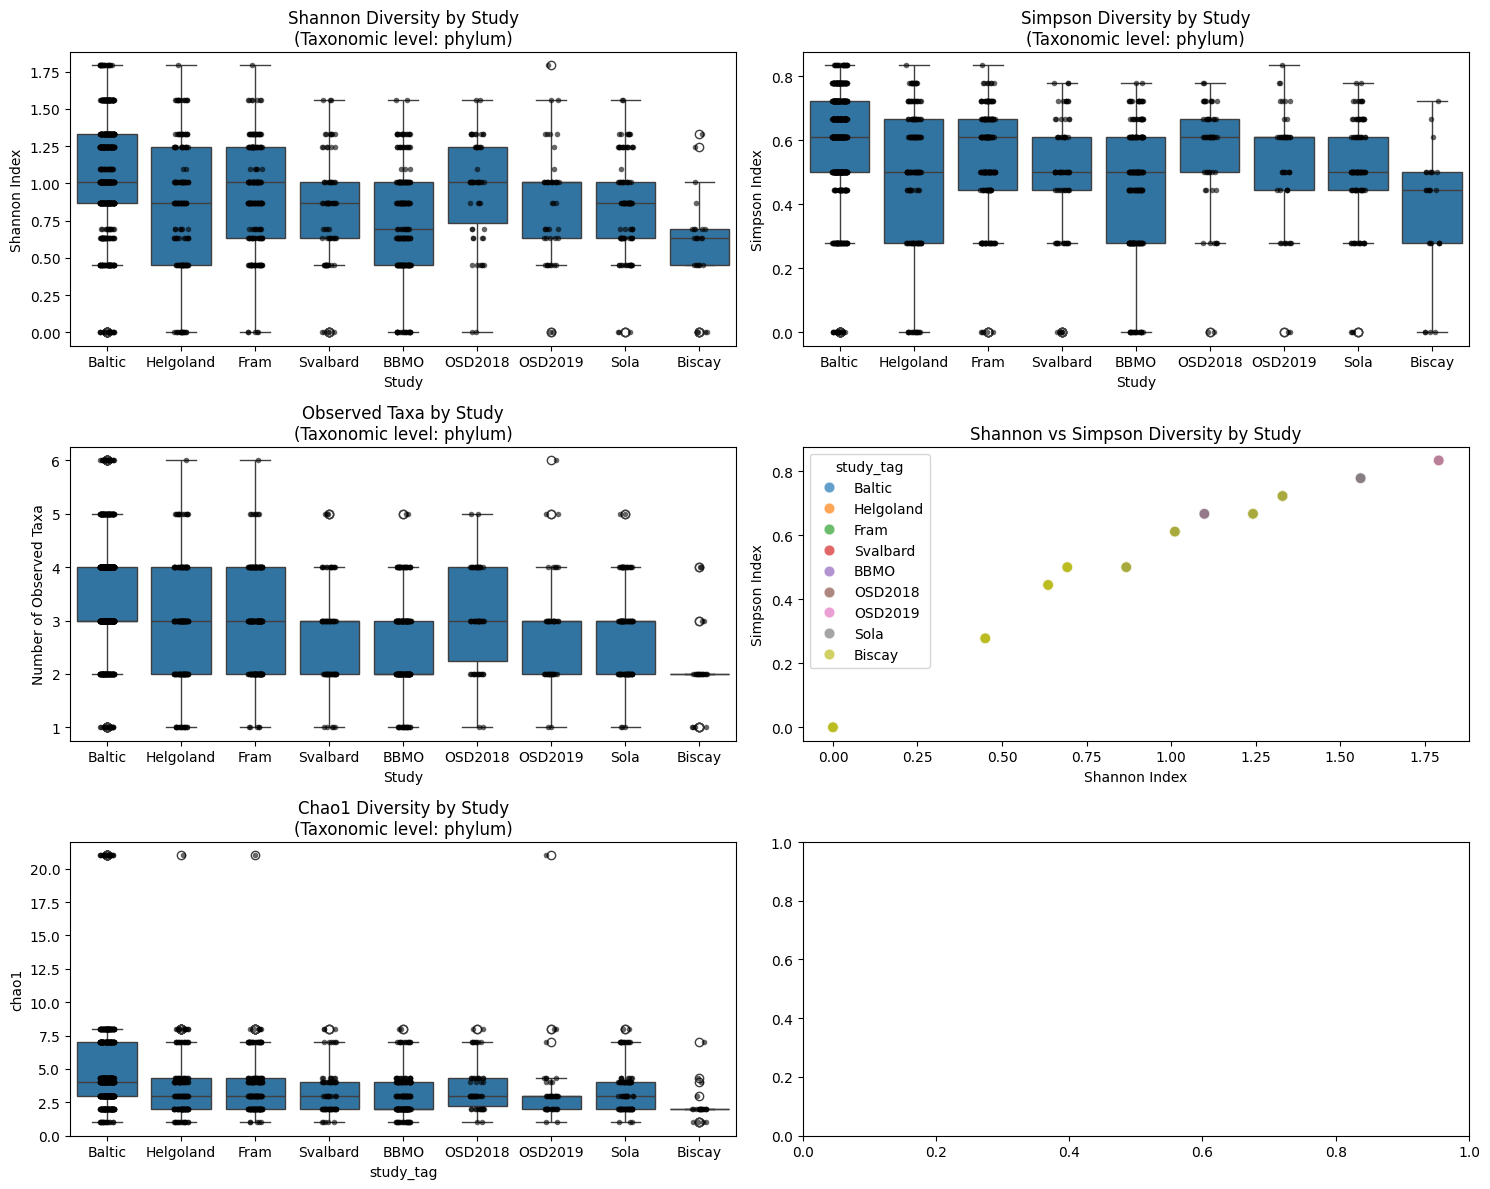

INFO | mgnify_methods.stats | 
INFO | mgnify_methods.stats | STATISTICAL COMPARISON OF ALPHA DIVERSITY BETWEEN STUDIES
INFO | mgnify_methods.stats | ============================================================
INFO | mgnify_methods.stats | 
SHANNON - Kruskal-Wallis
INFO | mgnify_methods.stats | H=172.139, p=0.0000, epsilon²=0.107
INFO | mgnify_methods.stats | 
SIMPSON - Kruskal-Wallis
INFO | mgnify_methods.stats | H=167.982, p=0.0000, epsilon²=0.104
INFO | mgnify_methods.stats | 
OBSERVED_OTUS - Kruskal-Wallis
INFO | mgnify_methods.stats | H=174.100, p=0.0000, epsilon²=0.108
INFO | mgnify_methods.stats | 
CHAO1 - Kruskal-Wallis
INFO | mgnify_methods.stats | H=160.173, p=0.0000, epsilon²=0.099


,Metric,Comparison,Test,Statistic,RawP,DeltaMedian,RBC,CliffDelta,KW_H,KW_P,KW_EpsilonSq,AdjP
0,shannon,Baltic vs Helgoland,Pairwise MW,68771.0,2.744863e-08,1.438410e-01,-0.278461,0.278461,172.139005,4.593145e-33,0.106515,8.783561e-07
1,shannon,Baltic vs Fram,Pairwise MW,83235.0,5.818642e-08,2.220446e-16,-0.250075,0.250075,172.139005,4.593145e-33,0.106515,1.803779e-06
2,shannon,Baltic vs Svalbard,Pairwise MW,35023.0,2.228619e-08,1.438410e-01,-0.386720,0.386720,172.139005,4.593145e-33,0.106515,7.354443e-07
3,shannon,Baltic vs BBMO,Pairwise MW,102276.0,2.988456e-25,3.182571e-01,-0.470835,0.470835,172.139005,4.593145e-33,0.106515,1.075844e-23
4,shannon,Baltic vs OSD2018,Pairwise MW,21521.5,9.499429e-02,0.000000e+00,-0.131282,0.131282,172.139005,4.593145e-33,0.106515,1.000000e+00
...,...,...,...,...,...,...,...,...,...,...,...,...
139,chao1,OSD2018 vs Sola,Pairwise MW,3306.5,4.777377e-01,0.000000e+00,-0.065582,0.065582,160.172727,1.471724e-30,0.098749,1.000000e+00
140,chao1,OSD2018 vs Biscay,Pairwise MW,1146.0,1.580769e-05,1.000000e+00,-0.580690,0.580690,160.172727,1.471724e-30,0.098749,4.268076e-04
141,chao1,OSD2019 vs Sola,Pairwise MW,2157.0,1.007674e-01,0.000000e+00,0.160047,-0.160047,160.172727,1.471724e-30,0.098749,1.000000e+00
142,chao1,OSD2019 vs Biscay,Pairwise MW,855.5,1.519010e-03,1.000000e+00,-0.425833,0.425833,160.172727,1.471724e-30,0.098749,3.189921e-02


In [16]:
abundance_table_alpha = abundance_table.copy()

logger.info("\n=== Calculating Minimum Rarefaction Depth ===")
MIN_DEPTH = calculate_min_rarefaction_depth(abundance_table_alpha)
logger.info(f"Minimum rarefaction depth determined: {MIN_DEPTH} reads")

abundance_table_alpha = rarefy_table(abundance_table_alpha, depth=MIN_DEPTH)


CONFIG['output']['alpha_tag'] = 'rarefied'
summary_case3, df_case3, stats_case3 = alpha_diversity_analysis(abundance_table_alpha, 
                                                   analysis_meta, samples_meta,
                                                   CONFIG)

## Comparison between treatments
- construct table like this

| Pipeline     | Metric  | Δmedian | Effect size | p     | Direction |
| ------------ | ------- | ------- | ----------- | ----- | --------- |
| Raw counts   | Shannon | +0.11   | 0.28        | 0.001 | OSD>SOLA  |
| CLR filtered | Shannon | +0.08   | 0.21        | 0.02  | OSD>SOLA  |
| Rarefied     | Shannon | +0.10   | 0.26        | 0.003 | OSD>SOLA  |

- calculate delta medians and effect sizes


In [18]:
# summary_case1.head()

In [19]:
# df_case1.head()

In [20]:
# stats_case1.head()

### Combine per metric

In [19]:
df = pd.concat([stats_case1, stats_case2, stats_case3], axis=0)

shannon_stats = df[df['Metric'] == 'shannon']
try:
    shannon_stats.index = ['No Processing', 'Remove Singletons', 'Rarefied']
except:
    pass
shannon_stats.head()


,Metric,Comparison,Test,Statistic,RawP,DeltaMedian,RBC,CliffDelta,KW_H,KW_P,KW_EpsilonSq,AdjP
0,shannon,Baltic vs Helgoland,Pairwise MW,76216.0,1.395668e-16,0.284769,-0.416865,0.416865,537.716321,5.644921e-111,0.343748,4.466138e-15
1,shannon,Baltic vs Fram,Pairwise MW,94441.0,1.930931e-19,0.201448,-0.418374,0.418374,537.716321,5.644921e-111,0.343748,6.372071e-18
2,shannon,Baltic vs Svalbard,Pairwise MW,38897.0,8.476347e-15,0.418536,-0.540109,0.540109,537.716321,5.644921e-111,0.343748,2.542904e-13
3,shannon,Baltic vs BBMO,Pairwise MW,127628.0,7.527369e-75,0.598679,-0.835423,0.835423,537.716321,5.644921e-111,0.343748,2.709853e-73
4,shannon,Baltic vs OSD2018,Pairwise MW,27196.0,5.725441e-08,0.216859,-0.429563,0.429563,537.716321,5.644921e-111,0.343748,1.030579e-06


In [ ]:
simpson_stats = df[df['Metric'] == 'simpson']
simpson_stats.index = ['No Processing', 'Remove Singletons', 'Rarefied']
simpson_stats.head()

,Metric,median OSD2018,median Sola,Delta Median,Rank Biserial Correlation,CliffDelta,U-Statistic,P-Value,direction
No Processing,simpson,0.698329,0.624790,0.073539,-0.456655,0.456655,4520.0,0.000001,OSD2018 > Sola
Remove Singletons,simpson,0.698154,0.624490,0.073664,-0.456655,0.456655,4520.0,0.000001,OSD2018 > Sola
Rarefied,simpson,0.697186,0.626994,0.070192,-0.457622,0.457622,4523.0,0.000001,OSD2018 > Sola


In [ ]:
otus_stats = df[df['Metric'] == 'observed_otus']
otus_stats.index = ['No Processing', 'Remove Singletons', 'Rarefied']
otus_stats.head()

,Metric,median OSD2018,median Sola,Delta Median,Rank Biserial Correlation,CliffDelta,U-Statistic,P-Value,direction
No Processing,observed_otus,37.5,31.0,6.5,-0.321624,0.321624,4101.0,0.000656,OSD2018 > Sola
Remove Singletons,observed_otus,28.0,22.0,6.0,-0.431679,0.431679,4442.5,0.000005,OSD2018 > Sola
Rarefied,observed_otus,29.0,26.0,3.0,-0.193039,0.193039,3702.0,0.040747,OSD2018 > Sola


In [ ]:
chao1_stats = df[df['Metric'] == 'chao1']
chao1_stats.index = ['No Processing', 'Remove Singletons', 'Rarefied']
chao1_stats.head()

,Metric,median OSD2018,median Sola,Delta Median,Rank Biserial Correlation,CliffDelta,U-Statistic,P-Value,direction
No Processing,chao1,46.071429,42.25,3.821429,-0.069771,0.069771,3319.5,0.460984,OSD2018 > Sola
Remove Singletons,chao1,28.000000,22.00,6.000000,-0.431679,0.431679,4442.5,0.000005,OSD2018 > Sola
Rarefied,chao1,39.000000,35.00,4.000000,-0.078311,0.078311,3346.0,0.407834,OSD2018 > Sola


## Summary

In [ ]:
print("\n" + "="*60)
print("ANALYSIS SUMMARY")
print("="*60)
print(f"Output folder: {OUT_FOLDER}")
print(f"\nDatasets analyzed: {list(ds.keys())}")
print(f"Total samples: {len(analysis_meta)}")
print(f"Sample type: {sample_type}")
print(f"\nTaxonomic level: {CONFIG['taxonomy']['analysis_level']}")
print(f"\nFiltering:")
print(f"  Min reads: {CONFIG['filtering']['min_reads_cutoff']}")
print(f"\nPrimary grouping feature: {CONFIG['feature']}")
print("="*60)


ANALYSIS SUMMARY
Output folder: /home/david-palecek/coding/emo-bon/mgnify-methods/mgnify-methods/notebooks/analysis_20260210_1432

Datasets analyzed: ['Sola', 'OSD2018']
Total samples: 165
Sample type: prok

Taxonomic level: phylum

Filtering:
  Min reads: 25000

Primary grouping feature: study_tag
